# **Speech Analysis Pipeline - Process Flow**

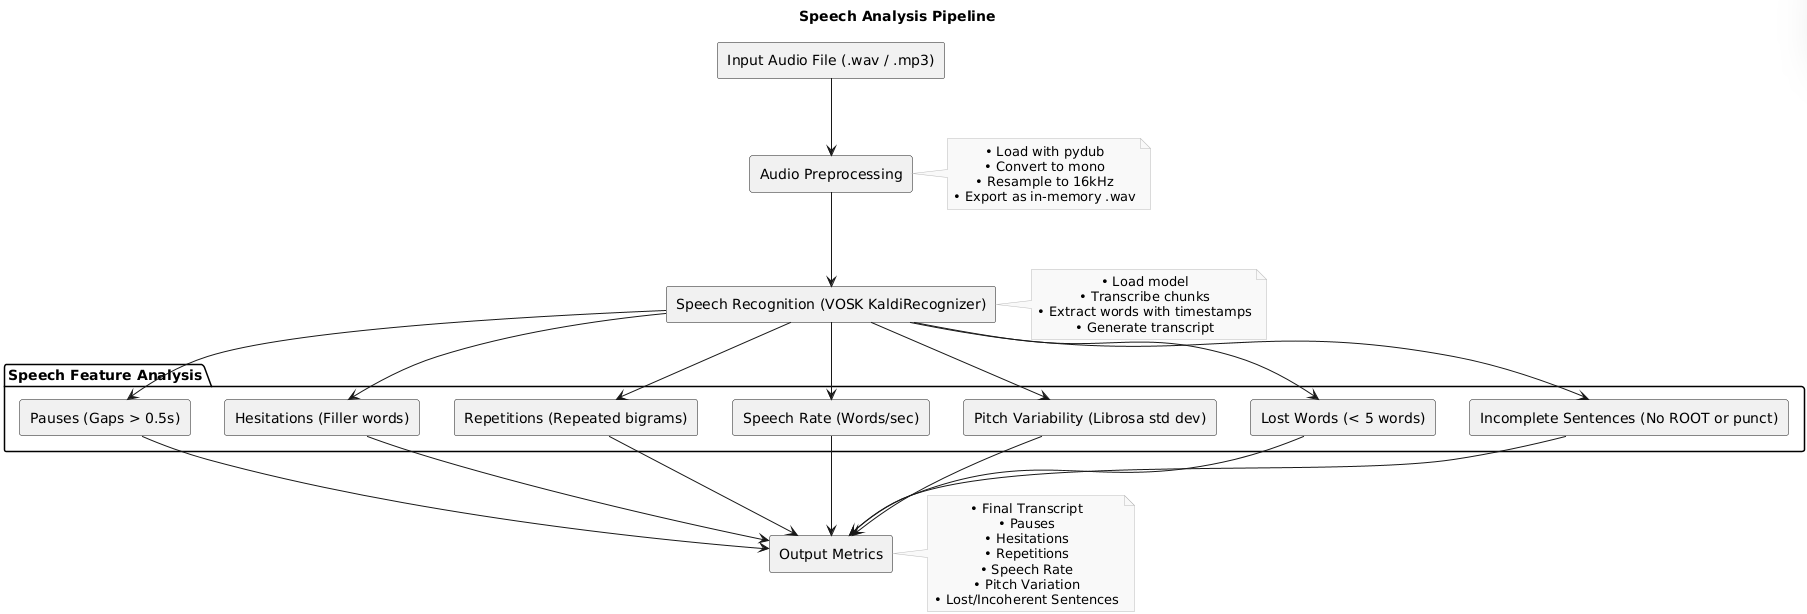

# **STEP-1:** Single voice clip Text Extraction 

## **Work Includes**

1. The below code uses the Vosk speech recognition model to convert the audio into text. Additionally, it captures the precise timing of each word's occurrence, which is very useful for verifying pauses and how fast someone is talking.

2. Feature Analysis: The extracted text column namely `transcript` was examined to determine many speech-related features:
   - **Pauses**: Detects prolonged pauses between words (more than 0.5 seconds), which can reflect a person thinking or stalling.
   - **Hesitation Markers**: Detects frequent filler words such as "um," "ah," "like," "you know," "well," "I mean," and "actually."
     
           - Filler Sounds: These are the basic sounds used to fill pauses, like "um," "uh," "ah," "er," and "hmm". 
           - Filler Phrases: These are short phrases used to give the speaker time to think or soften a statement, such as "you know," "I mean," "well," and "actually."
           - Discourse Markers: These are words that help connect ideas and guide the listener, but can also be used as fillers, like "so," "basically," and "really".
     
   - **Word Repetitions**: Identifies repeating word pairs, which may be an indication of difficulty remembering words or overstressing a point.
   - **Speech Rate**: Determines the number of words spoken in a single second.
   - **Pitch Variability**: Examines the variation of loudness that can be shown through emotion or emphasis.
   - **Incomplete Sentences**: Totals sentences which are extremely brief (fewer than 3 words), and possibly indicate incomplete thoughts.
   - **Lost or Forgotten Words**: Flags very short or truncated sentences that may indicate difficulty with word choice.



In [ ]:
pip install SpeechRecognition pydub

In [ ]:
!pip install vosk
!apt-get install -y libsndfile1
!wget https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip
!unzip -q vosk-model-small-en-us-0.15.zip

In [ ]:
from IPython.display import Audio
file_path = '/kaggle/input/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/REAL/musk-original.wav'
Audio(file_path)

In [ ]:
import os
import io
import wave
import json
from pydub import AudioSegment
from vosk import Model, KaldiRecognizer
from collections import Counter
import numpy as np
import re
import spacy
import librosa

nlp = spacy.load('en_core_web_sm')
input_audio_path = '/kaggle/input/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/REAL/musk-original.wav'  
model_path = 'vosk-model-small-en-us-0.15'

def prepare_audio_in_memory(input_path):
    print("Converting audio to 16kHz mono WAV (in-memory)...")
    audio = AudioSegment.from_file(input_path)
    audio = audio.set_channels(1).set_frame_rate(16000)
    audio_buffer = io.BytesIO()
    audio.export(audio_buffer, format="wav")
    audio_buffer.seek(0) 
    print("Conversion done.")
    return audio_buffer

def transcribe_with_metadata(audio_buffer, model_path):
    print("Starting transcription...")
    wf = wave.open(audio_buffer, "rb")
    if wf.getnchannels() != 1 or wf.getsampwidth() != 2 or wf.getframerate() != 16000:
        raise ValueError("Audio must be WAV format mono PCM 16kHz.")
    model = Model(model_path)
    recognizer = KaldiRecognizer(model, wf.getframerate())
    recognizer.SetWords(True) 
    results = []
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if recognizer.AcceptWaveform(data):
            results.append(json.loads(recognizer.Result()))
    results.append(json.loads(recognizer.FinalResult()))
    return results

def analyze_speech_features(results, audio):
    words = []
    full_text = []
    for res in results:
        if 'result' in res:
            words.extend(res['result'])
        if 'text' in res:
            full_text.append(res['text'])
    transcript = " ".join(full_text)
    print("\n--- Transcript ---\n", transcript)

    pauses = []
    for i in range(1, len(words)):
        gap = words[i]['start'] - words[i-1]['end']
        if gap > 0.5:  
            pauses.append((words[i-1]['word'], words[i]['word'], round(gap, 2)))

    hesitation_pattern = r"\b(uh|em|a|um|ah|erm|eh|hmm|mm|er|well|like|you know|I mean|so|actually|basically|literally|okay|right|sort of|kind of|just|I guess|maybe|alright)\b"
    hesitations = []
    for w in words:
        if re.match(hesitation_pattern, w['word'].lower()):
            hesitations.append(w['word'])

    word_list = [w['word'].lower() for w in words]
    bigrams = [(word_list[i], word_list[i+1]) for i in range(len(word_list)-1)]
    repetition_counts = Counter(bigrams)
    repetitions = [pair for pair, count in repetition_counts.items() if count > 1]

    total_duration = words[-1]['end'] - words[0]['start']
    speech_rate = len(words) / total_duration 

    y, sr = librosa.load(input_audio_path, sr=16000)  
    pitch, mag = librosa.core.piptrack(y=y, sr=sr) 
    pitch_variability = np.std(pitch[pitch > 0]) 
    lost_words = []  
    doc = nlp(transcript)
    for sent in doc.sents:
        if len(sent) < 5:  
            lost_words.append(sent.text)

    incomplete_sentences = [] 
    for sent in doc.sents:
        if sent[-1].dep_ not in ['punct', 'ROOT']:  
            incomplete_sentences.append(sent.text)

    return {
        "transcript": transcript,
        "pauses": pauses,
        "hesitations": hesitations,
        "repetitions": repetitions,
        "speech_rate_wps": round(speech_rate, 2),
        "word_count": len(words),
        "duration_sec": round(total_duration, 2),
        "pitch_variability": round(pitch_variability, 2),
        "lost_words": lost_words,
        "incomplete_sentences": incomplete_sentences
    }

if os.path.exists(input_audio_path):
    audio_buffer = prepare_audio_in_memory(input_audio_path)
    results = transcribe_with_metadata(audio_buffer, model_path)
    
    audio = AudioSegment.from_wav(input_audio_path)
    features = analyze_speech_features(results, audio)
    
    print("\n--- Analysis ---\n")
    for key, value in features.items():
        print(f"{key}:\n{value}\n")
else:
    print("Audio file not found. Please upload it to the notebook first.")

# **STEP - 2:** Dataset Creation and then Implementation of the our strategic model on the same
* As the Dataset of Audio with variety of cases are not available and also the the publically available dataset like 911 recordings, deep voice, audio based voilence, etc. contains the repetetive voices also and somewhaat has less number of unique dataset so we will take the unique dataset from each of them and then combine them to take under consideration for this task and then finally based on the detailing make them separate by the clusters.

# Case-1: On Emergency voice notes

In [ ]:
import pandas as pd
import os
import io
import wave
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
from pydub import AudioSegment
from vosk import Model, KaldiRecognizer
from tqdm.notebook import tqdm
import spacy

nlp = spacy.load("en_core_web_sm")
audio_dir = "/kaggle/input/emergency-voice-dataset"
model_path = "vosk-model-small-en-us-0.15"
model = Model(model_path)

def prepare_audio(audio_path):
    audio = AudioSegment.from_file(audio_path)
    audio = audio.set_channels(1).set_frame_rate(16000)
    buffer = io.BytesIO()
    audio.export(buffer, format="wav")
    buffer.seek(0)
    return buffer, audio

def transcribe_audio(audio_buffer):
    wf = wave.open(audio_buffer, "rb")
    recognizer = KaldiRecognizer(model, wf.getframerate())
    recognizer.SetWords(True)
    results = []
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if recognizer.AcceptWaveform(data):
            results.append(json.loads(recognizer.Result()))
    results.append(json.loads(recognizer.FinalResult()))
    return results

def analyze_features(results, audio):
    words = []
    full_text = []
    for res in results:
        if 'result' in res:
            words.extend(res['result'])
        if 'text' in res:
            full_text.append(res['text'])
    transcript = " ".join(full_text)

    pauses = []
    for i in range(1, len(words)):
        gap = words[i]['start'] - words[i-1]['end']
        if gap > 0.5:
            pauses.append((words[i-1]['word'], words[i]['word'], round(gap, 2)))

    hesitation_pattern = r"\b(uh|em|a|um|ah|erm|eh|hmm|mm|er|well|like|you know|I mean|so|actually|basically|literally|okay|right|sort of|kind of|just|I guess|maybe|alright)\b"
    hesitations = [w['word'].lower() for w in words if re.match(hesitation_pattern, w['word'].lower())]
    unique_hesitations = set(hesitations)

    word_list = [w['word'].lower() for w in words]
    bigrams = [(word_list[i], word_list[i+1]) for i in range(len(word_list)-1)]
    repetition_counts = Counter(bigrams)
    repetitions = [pair for pair, count in repetition_counts.items() if count > 1]

    duration = words[-1]['end'] - words[0]['start'] if words else 1
    speech_rate = len(words) / duration if duration > 0 else 0

    loudness = np.array(audio.get_array_of_samples())
    pitch_variability = round(np.max(loudness) - np.min(loudness), 2)

    sentences = transcript.split('.')
    num_incomplete = len([s for s in sentences if len(s.strip().split()) < 3])

    lost_words = []
    doc = nlp(transcript)
    for sent in doc.sents:
        if len(sent) < 5:
            lost_words.append(sent.text.strip())

    return {
        "transcript": transcript,
        "num_pauses": len(pauses),
        "pauses": pauses,
        "unique_hesitations": list(unique_hesitations),
        "num_hesitations": len(hesitations),
        "repetitions": repetitions,
        "num_word_recalls": len([pair for pair in repetitions if pair[0] == pair[1]]),
        "speech_rate": round(speech_rate, 2),
        "pitch_variability": pitch_variability,
        "num_incomplete_sentences": num_incomplete,
        "word_count": len(words),
        "lost_words": lost_words,
        "num_lost": len(lost_words),
        "count": 1
    }

all_features = []
for root, _, files in os.walk(audio_dir):
    for filename in tqdm([f for f in files if f.endswith(".wav")]):
        filepath = os.path.join(root, filename)
        try:
            buffer, audio = prepare_audio(filepath)
            results = transcribe_audio(buffer)
            features = analyze_features(results, audio)
            features['file'] = filename
            all_features.append(features)
        except Exception as e:
            print(f"Failed on {filename}: {e}")

cols = [
    'file', 'pauses', 'transcript', 'num_pauses', 'unique_hesitations', 'num_hesitations',
    'repetitions', 'num_word_recalls', 'speech_rate', 'pitch_variability',
    'num_incomplete_sentences', 'word_count', 'lost_words', 'num_lost', 'count'
]
df = pd.DataFrame(all_features, columns=cols)
df.to_csv("audio_speech_feature_analysis.csv", index=False)
df.head()

In [ ]:
df1 = pd.read_csv("/kaggle/working/audio_speech_feature_analysis.csv")

In [ ]:
df1.head(10)

# Case-2: On Regular voice notes

In [ ]:
import os
import io
import wave
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
from pydub import AudioSegment
from vosk import Model, KaldiRecognizer
from tqdm.notebook import tqdm
import spacy

nlp = spacy.load("en_core_web_sm")
audio_dir = "/kaggle/input/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/REAL"
model_path = "vosk-model-small-en-us-0.15"
model = Model(model_path)

def prepare_audio(audio_path):
    audio = AudioSegment.from_file(audio_path)
    audio = audio.set_channels(1).set_frame_rate(16000)
    buffer = io.BytesIO()
    audio.export(buffer, format="wav")
    buffer.seek(0)
    return buffer, audio

def transcribe_audio(audio_buffer):
    wf = wave.open(audio_buffer, "rb")
    recognizer = KaldiRecognizer(model, wf.getframerate())
    recognizer.SetWords(True)
    results = []
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if recognizer.AcceptWaveform(data):
            results.append(json.loads(recognizer.Result()))
    results.append(json.loads(recognizer.FinalResult()))
    return results

def analyze_features(results, audio):
    words = []
    full_text = []
    for res in results:
        if 'result' in res:
            words.extend(res['result'])
        if 'text' in res:
            full_text.append(res['text'])
    transcript = " ".join(full_text)

    pauses = []
    for i in range(1, len(words)):
        gap = words[i]['start'] - words[i-1]['end']
        if gap > 0.5:
            pauses.append((words[i-1]['word'], words[i]['word'], round(gap, 2)))

    hesitation_pattern = r"\b(uh|em|a|um|ah|erm|eh|hmm|mm|er|well|like|you know|I mean|so|actually|basically|literally|okay|right|sort of|kind of|just|I guess|maybe|alright)\b"
    hesitations = [w['word'].lower() for w in words if re.match(hesitation_pattern, w['word'].lower())]
    unique_hesitations = set(hesitations)

    word_list = [w['word'].lower() for w in words]
    bigrams = [(word_list[i], word_list[i+1]) for i in range(len(word_list)-1)]
    repetition_counts = Counter(bigrams)
    repetitions = [pair for pair, count in repetition_counts.items() if count > 1]

    duration = words[-1]['end'] - words[0]['start'] if words else 1
    speech_rate = len(words) / duration if duration > 0 else 0

    loudness = np.array(audio.get_array_of_samples())
    pitch_variability = round(np.max(loudness) - np.min(loudness), 2)

    sentences = transcript.split('.')
    num_incomplete = len([s for s in sentences if len(s.strip().split()) < 3])

    lost_words = []
    doc = nlp(transcript)
    for sent in doc.sents:
        if len(sent) < 5:
            lost_words.append(sent.text.strip())

    return {
        "transcript": transcript,
        "num_pauses": len(pauses),
        "pauses": pauses,
        "unique_hesitations": list(unique_hesitations),
        "num_hesitations": len(hesitations),
        "repetitions": repetitions,
        "num_word_recalls": len([pair for pair in repetitions if pair[0] == pair[1]]),
        "speech_rate": round(speech_rate, 2),
        "pitch_variability": pitch_variability,
        "num_incomplete_sentences": num_incomplete,
        "word_count": len(words),
        "lost_words": lost_words,
        "num_lost": len(lost_words),
        "count": 1
    }

all_features = []
for root, _, files in os.walk(audio_dir):
    for filename in tqdm([f for f in files if f.endswith(".wav")]):
        filepath = os.path.join(root, filename)
        try:
            buffer, audio = prepare_audio(filepath)
            results = transcribe_audio(buffer)
            features = analyze_features(results, audio)
            features['file'] = filename
            all_features.append(features)
        except Exception as e:
            print(f"Failed on {filename}: {e}")

cols = [
    'file', 'pauses', 'transcript', 'num_pauses', 'unique_hesitations', 'num_hesitations',
    'repetitions', 'num_word_recalls', 'speech_rate', 'pitch_variability',
    'num_incomplete_sentences', 'word_count', 'lost_words', 'num_lost', 'count'
]
df = pd.DataFrame(all_features, columns=cols)
df.to_csv("audio_speech_feature_analysis1.csv", index=False)
df.head()

In [ ]:
df2 = pd.read_csv("/kaggle/working/audio_speech_feature_analysis1.csv")

In [ ]:
df2.head(8)

# Combining the Datasets to get a robust Dataset for this task

In [ ]:
# Concatenate and reset index
df_combined = pd.concat([df1, df2], ignore_index=True)

In [ ]:
df_combined.head(5)

In [ ]:
df_combined.to_csv("audio_speech_feature_analysis_report.csv", index=False)

# Emergency case aanalysis 
Detection of the emergency case and the level of emergency so that the necessary action can be taken plaace according to priority based on level if multiple emergency cases are seen at a time 

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("audio_speech_feature_analysis_report.csv")
emergency_keywords = {
    'help': 2, 'cocaine': 2,
    'emergency': 3, 'urgent': 3, 'scared': 3, 'police': 3, 'hurt': 3,
    'accident': 4, 'hospital': 4, 'victim': 4,
    'fire': 5, 'injured': 5, 'ambulance': 5, 'crash': 5,
    'bleeding': 6, 'gun': 6, 'dead': 6,
    'shot': 7, 'stabbed': 7, 'shooting': 7, 'murder': 7, 'gunshot': 7
}
max_importance = max(emergency_keywords.values())

def compute_emergency_score(text):
    text = text.lower()
    words = re.findall(r'\w+', text)
    found = [emergency_keywords.get(word, 0) for word in words]
    return max(found) / max_importance if found else 0.0

df["emergency_score"] = df["transcript"].fillna("").apply(compute_emergency_score)
def classify_emergency(score):
    if score == 0 :
        return "normal"
    if score < 0.45:
        return "low"
    elif score < 0.65:
        return "moderate"
    else:
        return "high"

df["emergency_level"] = df["emergency_score"].apply(classify_emergency)
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(df["transcript"].fillna(""))

level_to_cluster = {
    "normal": 0,
    "low": 1,
    "moderate": 2,
    "high": 4
}
df["cluster"] = df["emergency_level"].map(level_to_cluster)

high_mask = df["emergency_level"] == "high"
if high_mask.sum() > 0:
    high_indices = high_mask.to_numpy().nonzero()[0]
    high_vectors = X_tfidf[high_indices].toarray()
    centroid = np.mean(high_vectors, axis=0).reshape(1, -1)
    df["similarity_score"] = cosine_similarity(X_tfidf.toarray(), centroid).flatten()
else:
    df["similarity_score"] = 0.0

df.to_csv("final_emergency_clustered_analysis.csv", index=False)
print("Final analysis is saved to final_emergency_clustered_analysis.csv")

In [ ]:
df.head(10)